# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

*Answers - Q1*

1. Linear models can't accomodate reasonable restrictions on the outcomes since they can only output values from negative infinity to infinity which doesn't work well for things like probabilities. That's why we also rely on general linear models/latent variable models/activation functions; these models can fix this issue by applying an activation function to the linear outupt so we can keep the interpretability of linear models and restrict the output to a meaningful range.
2. Binary and categorical cross entropy are effective loss functions for logistic regression because they measure how close the model's predicted probabilities are to the true labels. Logistic regression outputs values between 0 and 1 (interpreted as probabilities) and cross entropy evaluates the accuracy of these probabilities.
3. True - Logistic regression is a linear model because its foundation is a linear combination of the input features; passing the linear output through a nonlinear activiation function (sigmoid) is what maps the output to a probability between 0 and 1.
4. False - Logistic regression can be used for classification by selecting a threshold that separates the different classes. For instance, probability >= 0.5 is class 1 and probability < 0 is class 0.
5. No, in logistic regression the coefficient represents the change in the log-odds of the otucome for a 1 unit increase in the explanatory variable becuase of the nonlinear sigmoid transformation.
6. False - Feature engineering is still necessary because the underlying relationship between the features and the log-odds is still linear, so we need feature engineering such as adding interaction and higher-order terms to help the model learn complex relationships.
7. False - Logistic regression is suitable for certain cases, specifically for classification and outputs that are more meaningful as probabilities; however, that does not detract from the cases where the usual linear model would be more suitable, such as for regression and continuous outputs.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [ ]:
### 2.1

df = pd.read_csv("data/data.csv", delimiter=";")
df = df.loc[:, ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment", "Curricular units 1st sem (approved)", "Target"]]
df["Target"] = df["Target"].map({"Dropout": "1", "Graduate": "0", "Enrolled": "0"})

print(len(df))
df.dropna()
len(df) # there were no missing values

4424


4424

In [5]:
### 2.2
from sklearn.linear_model import LogisticRegression

X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["Target"].astype(int)

model = LogisticRegression()
model.fit(X, y)

print(pd.Series(model.coef_[0], index=X.columns))

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


The variables that predict higher dropout probability are debtor and age at enrollment (slightly), while tuition fees up to date and scholarship holder predict a lower dropout probability. Yes, being up to date on tuition fees seems to reduce dropout risk.

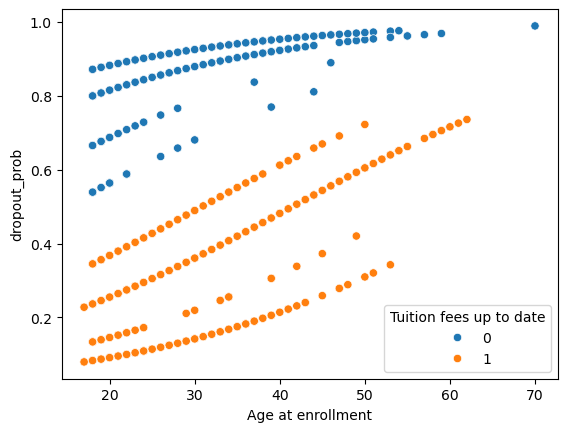

Tuition fees up to date
0    0.860675
1    0.248090
Name: dropout_prob, dtype: float64
-0.612584933973764


In [7]:
### 2.3
df["dropout_prob"] = model.predict_proba(X)[:, 1]
sns.scatterplot(data=df, x="Age at enrollment", y="dropout_prob", hue="Tuition fees up to date")
plt.show()

avg_probs = df.groupby("Tuition fees up to date")["dropout_prob"].mean()
print(avg_probs)

avg_change = avg_probs[1] - avg_probs[0]
print(avg_change)


Being up to date lowers dropout probability by ~61%. It also seems like being up to date on tuition reduces dropout probability by a similar amount across all ages, as there isn’t a specific age where the effect is clearly bigger by just visually examining the graph.

In [ ]:
### 2.4 
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print(cm)

acc = accuracy_score(y, y_pred)
print("Accuracy:", acc) # The accuracy is ~76%

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


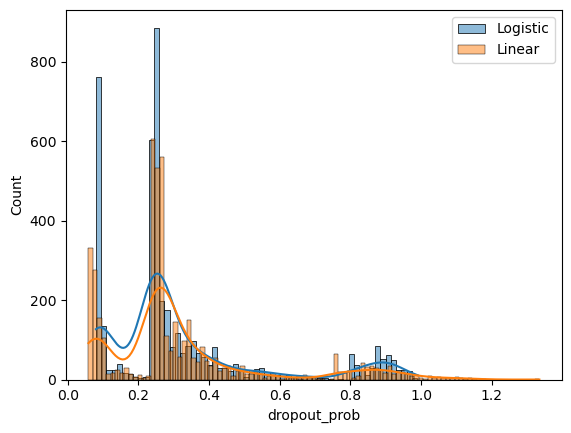

In [9]:
### 2.5
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_prob"] = lin_model.predict(X)

sns.histplot(df["dropout_prob"], label="Logistic", kde=True)
sns.histplot(df["lin_prob"], label="Linear", kde=True)

plt.legend()
plt.show()

Logistic regression performs better because it produces valid probabilities between 0 and 1, while the linear model gives unrealistic values outside this range.

##### 2.6
Students most at risk are those with debt, not up to date on tuition, without scholarships, older, and with fewer approved courses, so interventions could include financial support, scholarships, and academic advising to help students stay enrolled.

In [10]:
### 2.7
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_multi = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = pd.read_csv("data/data.csv", delimiter=";")["Target"]

# multinomial logistic regression
multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

# predictions (hard classification)
y_pred_multi = multi_model.predict(X_multi)

# confusion matrix
cm_multi = confusion_matrix(y_multi, y_pred_multi)
print(cm_multi)

# predicted probabilities
probs_multi = multi_model.predict_proba(X_multi)
print(probs_multi[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Based on the confusion matrix, it seems like the model never predicts the second class (since the second column is all zeroes), so it mostly just predicts either graduate or dropout, meaning the hard classification misses the enrolled class. However, the predicted probabilities include all classes, meaning the model still considers each class but does not select some of them as the most likely outcome.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [20]:
df.head()

,Bilirubin,Edema,Drug,Stage,Status,Status_New
0,14.5,Y,D-penicillamine,4.0,D,0
1,1.1,N,D-penicillamine,3.0,C,1
2,1.4,S,D-penicillamine,4.0,D,0
3,1.8,S,D-penicillamine,4.0,D,0
4,3.4,N,Placebo,3.0,CL,1


In [ ]:
### 3.1
df = pd.read_csv("data/cirrhosis.csv")
df = df.loc[:, ["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

print(len(df))
df = df.dropna() # dropped missing values using df.dropna()
len(df)

418


312

In [19]:
### 3.2
X = pd.get_dummies(df[["Edema", "Drug", "Bilirubin"]], drop_first=True)
df["Status_New"] = df["Status"].map({"C": 1, "CL": 1, "D": 0})
y = df["Status_New"]

model = LogisticRegression()
model.fit(X,y)

print(pd.Series(model.coef_[0], index=X.columns))


Bilirubin      -0.351424
Edema_S        -0.450677
Edema_Y        -1.611049
Drug_Placebo    0.231225
dtype: float64


Yes, the drug seems to improve survival probability. A higher bilirubin is associated with a lower survival rate (since the coefficient is negative). And survival rate decreases as edema worsens and this relationship is stronger for Edema_Y (edema despite dirutics) than for Edema_S (edema resolvable with dirutics).

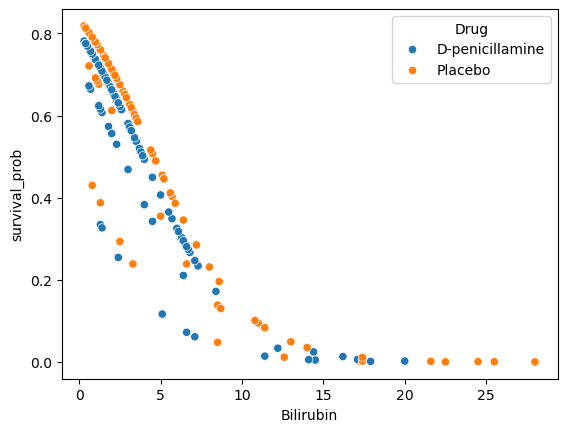

Drug
D-penicillamine    0.590054
Placebo            0.608902
Name: survival_prob, dtype: float64
-0.018848501038509213


In [23]:
### 3.3
df["survival_prob"] = model.predict_proba(X)[:, 1]
sns.scatterplot(data=df, x="Bilirubin", y="survival_prob", hue="Drug")
plt.show()

avg_probs = df.groupby("Drug")["survival_prob"].mean()
print(avg_probs)

avg_change = avg_probs["D-penicillamine"] - avg_probs["Placebo"]
print(avg_change)

Just by looking at the scatterplot, the drug does not appear to increase survival at any bilirubin level, as survival probabilities are very similar or slightly lower than placebo. On average, the drug decreases survival probability by about 2%.

In [25]:
### 3.4

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print(cm)

acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)    # The accuracy is ~74%

[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


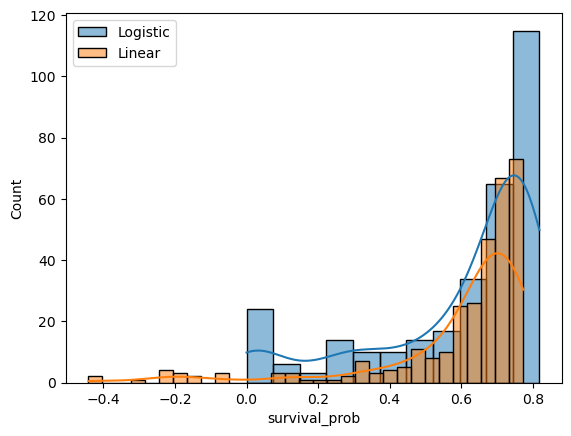

In [26]:
### 3.5
lin_model = LinearRegression()
lin_model.fit(X, y)

df["lin_survival_prob"] = lin_model.predict(X)

sns.histplot(df["survival_prob"], label="Logistic", kde=True)
sns.histplot(df["lin_survival_prob"], label="Linear", kde=True)

plt.legend()
plt.show()

Logistic regression performs better since it produces valid probabilities between 0 and 1, whereas the linear model gives invalid values (such as negative probabilities).

In [27]:
### 3.6
X_stage = pd.get_dummies(df[["Edema", "Bilirubin"]], drop_first=True)
y_stage = df["Stage"]

stage_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
stage_model.fit(X_stage, y_stage)
y_pred_stage = stage_model.predict(X_stage)

cm_stage = confusion_matrix(y_stage, y_pred_stage)
print(cm_stage)

probs_stage = stage_model.predict_proba(X_stage)
print(probs_stage[:5])

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


c:\Users\shalm\miniconda3\envs\pysparkenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The hard classification does not predict every class as the first two columns of the confusion matrix are all zeroes, indicating that the first and second classes aren't predicted and only Stage 3 and 4 are. On the other hand, the predicted probabilities include all 4 classes.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

##### 4.1
The derivative of prediction with respect to the k-th feature is $\hat{y}' = b_k$. For a 1-unit change in the feature, the prediction changes by $b_k$.

##### 4.2

The derivative with respect to the k-th feature is:
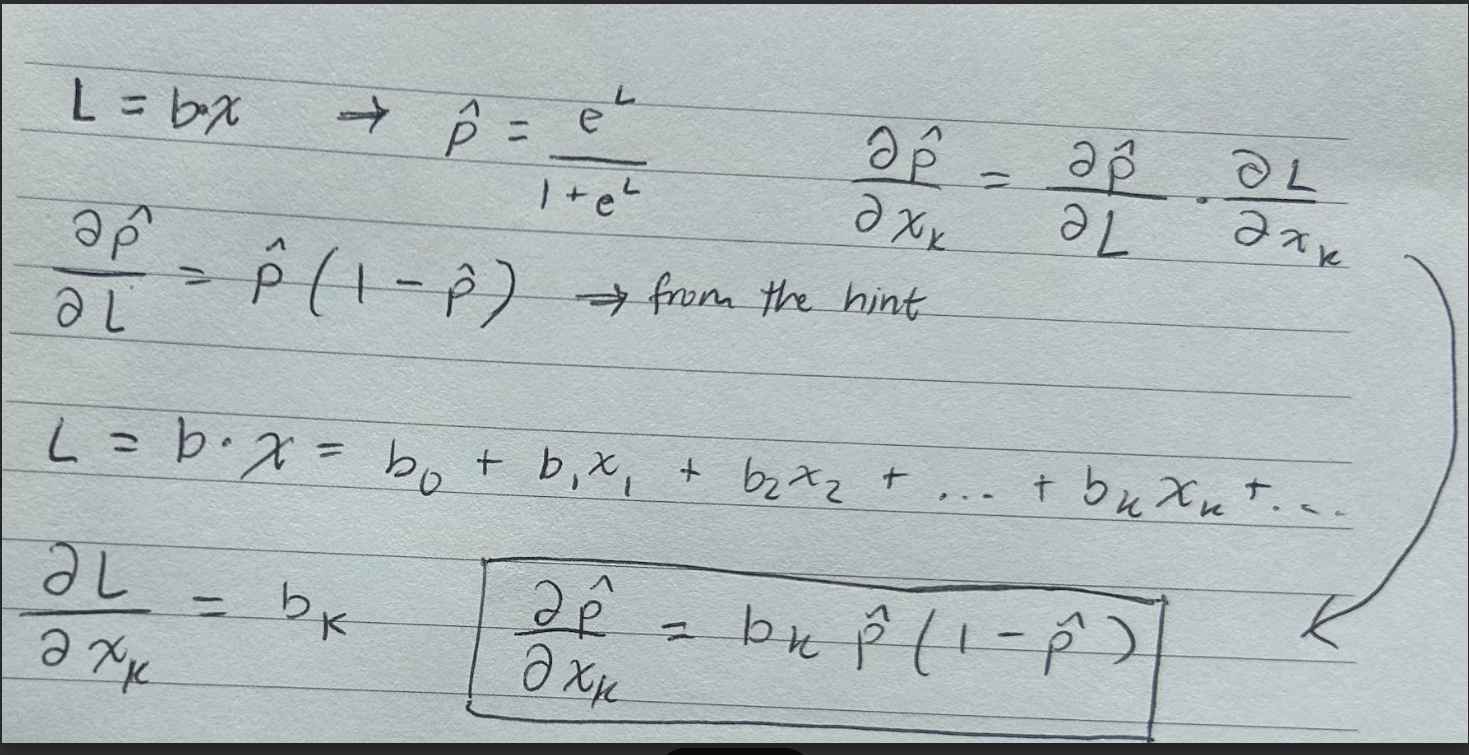

Unlike the linear model, the effect on x depends on $\hat{p}$ and is not constant. The effect is largest when $\hat{p}$ is around 0.5 and small when $\hat{p}$ is near 0 or 1. The coefficient (times 4) is a good estimate when $\hat{p} \approx 0.5$.

##### 4.3

A 1-unit change in $x_k$ increases the log-odds by $b_k$.